In [132]:
#importing required libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from groq import Groq
import re
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import plotly.express as px

In [133]:
pd.set_option('display.max_colwidth', None)

### Task 1: Data Collection & Preprocessing

#### Data Analysing

In [134]:
#reading csv file
data=pd.read_csv("Fraud Detection Data.csv")

In [135]:
data.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


In [136]:
data.shape

(2512, 16)

In [137]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [138]:
data.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [139]:
data.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [140]:
df=data.copy()

In [141]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


#### Data Transformation

In [142]:
df['TransactionDate']=pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y %H:%M')
df['PreviousTransactionDate']=pd.to_datetime(df['PreviousTransactionDate'], format='%d-%m-%Y %H:%M')

In [143]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:00
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:00
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:00
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:00
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:00


In [144]:
df['TransactionHour']=df['TransactionDate'].dt.hour
df['TransactionDay'] = df['TransactionDate'].dt.day
df['TransactionMonth'] = df['TransactionDate'].dt.month

In [145]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionHour,TransactionDay,TransactionMonth
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:00,16,11,4
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:00,16,27,6
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:00,18,10,7
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:00,16,5,5
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:00,17,16,10


In [146]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
TransactionHour            0
TransactionDay             0
TransactionMonth           0
dtype: int64

In [147]:
df = df.sort_values(by=['AccountID', 'TransactionDate']).reset_index(drop=True)

df['PrevTxn'] = df.groupby('AccountID')['TransactionDate'].shift(1)

df['TimeDiff'] = (df['TransactionDate'] - df['PrevTxn']).dt.total_seconds()/60

df['TimeDiff'] = df['TimeDiff'].fillna(0)

In [148]:
df['HighLoginAttempts'] = (df['LoginAttempts'] >= 3).astype(int)
df['FastTransaction'] = (df['TransactionDuration'] <= 2).astype(int)
df['RapidTransactions'] = (df['TimeDiff'] < 60).astype(int)
df['LogTimeDiff'] = np.log1p(df['TimeDiff'])
df['HighAmount'] = (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.9)).astype(int)
df['VeryRapid'] = (df['TimeDiff'] < 60).astype(int)

In [149]:
features = [
    'TransactionAmount',
    'LogTimeDiff',
    'TimeDiff',
    'LoginAttempts',
    'TransactionDuration',
    'AccountBalance',
    'HighLoginAttempts',
    'FastTransaction',
    'RapidTransactions',
    'HighAmount',
    'Channel',
    'VeryRapid'
]
df=df[features]

In [150]:
df.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid
0,47.79,0.000000,0.0,1,37,1649.92,0,0,1,0,Branch,1
1,212.97,11.366708,86396.0,1,178,4180.40,0,0,0,0,Online,0
2,476.99,0.000000,0.0,1,187,1154.48,0,0,1,0,Online,1
3,59.32,11.164743,70596.0,1,38,5750.89,0,0,0,0,Branch,0
4,12.62,11.462053,95039.0,1,61,6420.47,0,0,0,0,Branch,0


In [151]:
cols = ['Channel']

le = LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])

In [152]:
df.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid
0,47.79,0.000000,0.0,1,37,1649.92,0,0,1,0,1,1
1,212.97,11.366708,86396.0,1,178,4180.40,0,0,0,0,2,0
2,476.99,0.000000,0.0,1,187,1154.48,0,0,1,0,2,1
3,59.32,11.164743,70596.0,1,38,5750.89,0,0,0,0,1,0
4,12.62,11.462053,95039.0,1,61,6420.47,0,0,0,0,1,0


In [153]:
df['LoginAttempts'].value_counts()

LoginAttempts
1    2390
5      32
4      32
3      31
2      27
Name: count, dtype: int64

In [154]:
df['TransactionDuration'].describe()

count    2512.000000
mean      119.643312
std        69.963757
min        10.000000
25%        63.000000
50%       112.500000
75%       161.000000
max       300.000000
Name: TransactionDuration, dtype: float64

In [155]:
df.shape

(2512, 12)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    2512 non-null   float64
 1   LogTimeDiff          2512 non-null   float64
 2   TimeDiff             2512 non-null   float64
 3   LoginAttempts        2512 non-null   int64  
 4   TransactionDuration  2512 non-null   int64  
 5   AccountBalance       2512 non-null   float64
 6   HighLoginAttempts    2512 non-null   int64  
 7   FastTransaction      2512 non-null   int64  
 8   RapidTransactions    2512 non-null   int64  
 9   HighAmount           2512 non-null   int64  
 10  Channel              2512 non-null   int64  
 11  VeryRapid            2512 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 235.6 KB


In [157]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

In [158]:
df_scaled.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid
0,-0.855820,-1.929020,-0.855203,-0.206794,-1.181466,-0.888266,-0.198255,0.0,1.978851,-0.333923,0.010826,1.978851
1,-0.289919,0.630178,0.315185,-0.206794,0.834265,-0.239452,-0.198255,0.0,-0.505344,-0.333923,1.247014,-0.505344
2,0.614606,-1.929020,-0.855203,-0.206794,0.962929,-1.015296,-0.198255,0.0,1.978851,-0.333923,1.247014,1.978851
3,-0.816319,0.584706,0.101146,-0.206794,-1.167170,0.163220,-0.198255,0.0,-0.505344,-0.333923,0.010826,-0.505344
4,-0.976312,0.651645,0.432270,-0.206794,-0.838362,0.334900,-0.198255,0.0,-0.505344,-0.333923,0.010826,-0.505344


In [159]:
df.describe()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.0,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,8.567765,63129.599124,1.124602,119.643312,5114.302966,0.037818,0.0,0.203424,0.100318,0.991242,0.203424
std,291.946243,4.442397,73832.976547,0.602662,69.963757,3900.942499,0.190795,0.0,0.402625,0.300484,0.809100,0.402625
min,0.260000,0.000000,0.000000,1.000000,10.000000,101.250000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,81.885000,8.663239,5785.250000,1.000000,63.000000,1504.370000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
50%,211.140000,10.568711,38897.500000,1.000000,112.500000,4735.510000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000
75%,414.527500,11.446265,93550.250000,1.000000,161.000000,7678.820000,0.000000,0.0,0.000000,0.000000,2.000000,0.000000
max,1919.110000,13.018615,450725.000000,5.000000,300.000000,14977.990000,1.000000,0.0,1.000000,1.000000,2.000000,1.000000


### Task 2: Anomaly Detection using Unsupervised ML

#### Model for anomaly detection

In [160]:
model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)

In [161]:
# Fit the model
model.fit(df_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [162]:
# Predict anomalies: 1 for normal, -1 for anomaly
predictions = model.predict(df_scaled)

In [163]:
# Get raw anomaly scores (lower/more negative = more anomalous)
scores = model.decision_function(df_scaled)

In [164]:
scores

array([0.15276649, 0.23037163, 0.13045466, ..., 0.22991768, 0.19401591,
       0.15745564], shape=(2512,))

In [165]:
df['Anomaly'] = model.predict(df_scaled)

In [166]:
df.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid,Anomaly
0,47.79,0.000000,0.0,1,37,1649.92,0,0,1,0,1,1,1
1,212.97,11.366708,86396.0,1,178,4180.40,0,0,0,0,2,0,1
2,476.99,0.000000,0.0,1,187,1154.48,0,0,1,0,2,1,1
3,59.32,11.164743,70596.0,1,38,5750.89,0,0,0,0,1,0,1
4,12.62,11.462053,95039.0,1,61,6420.47,0,0,0,0,1,0,1


In [167]:
#Making it readable to understand which is fraud and which is not
df['Fraud'] = df['Anomaly'].apply(lambda x: 1 if x == -1 else 0)
df.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid,Anomaly,Fraud
0,47.79,0.000000,0.0,1,37,1649.92,0,0,1,0,1,1,1,0
1,212.97,11.366708,86396.0,1,178,4180.40,0,0,0,0,2,0,1,0
2,476.99,0.000000,0.0,1,187,1154.48,0,0,1,0,2,1,1,0
3,59.32,11.164743,70596.0,1,38,5750.89,0,0,0,0,1,0,1,0
4,12.62,11.462053,95039.0,1,61,6420.47,0,0,0,0,1,0,1,0


In [168]:
df['Fraud'].value_counts()

Fraud
0    2461
1      51
Name: count, dtype: int64

In [169]:
fraud_df = df[df['Fraud'] == 1]

fraud_df.head()

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid,Anomaly,Fraud
54,733.29,0.000000,0.0,5,94,10427.00,1,0,1,1,0,1,-1,1
84,774.48,0.000000,0.0,1,31,11613.58,0,0,1,1,1,1,-1,1
99,1228.81,0.000000,0.0,1,254,1821.00,0,0,1,1,0,1,-1,1
100,331.32,11.926683,151248.0,5,137,13054.54,1,0,0,0,1,0,-1,1
203,737.46,0.000000,0.0,4,75,634.16,1,0,1,1,1,1,-1,1


In [170]:
fraud_df[['TransactionAmount', 'LogTimeDiff', 'LoginAttempts']].describe()

,TransactionAmount,LogTimeDiff,LoginAttempts
count,51.000000,51.000000,51.000000
mean,552.458824,4.764612,3.647059
std,473.159447,5.374205,1.533930
min,6.300000,0.000000,1.000000
25%,173.355000,0.000000,3.000000
50%,441.260000,0.000000,4.000000
75%,800.810000,10.508999,5.000000
max,1531.310000,12.844666,5.000000


In [171]:
df['AnomalyScore'] = model.decision_function(df_scaled)

df['AnomalyScore'].describe()

count    2512.000000
mean        0.174822
std         0.063820
min        -0.093585
25%         0.143625
50%         0.193598
75%         0.223668
max         0.259540
Name: AnomalyScore, dtype: float64

In [172]:
fraud_ratio = df['Fraud'].mean()
print(fraud_ratio)

0.020302547770700636


In [173]:
df_sorted = df.sort_values(by='AnomalyScore')

df_sorted.head(10)

,TransactionAmount,LogTimeDiff,TimeDiff,LoginAttempts,TransactionDuration,AccountBalance,HighLoginAttempts,FastTransaction,RapidTransactions,HighAmount,Channel,VeryRapid,Anomaly,Fraud,AnomalyScore
54,733.29,0.000000,0.0,5,94,10427.00,1,0,1,1,0,1,-1,1,-0.093585
483,827.14,0.000000,0.0,4,265,9800.21,1,0,1,1,1,1,-1,1,-0.088877
203,737.46,0.000000,0.0,4,75,634.16,1,0,1,1,1,1,-1,1,-0.071320
429,1531.31,11.400507,89366.0,4,62,859.86,1,0,0,1,2,0,-1,1,-0.054749
550,238.54,0.000000,0.0,4,12,868.91,1,0,1,0,0,1,-1,1,-0.052784
843,39.21,0.000000,0.0,4,245,9385.57,1,0,1,0,0,1,-1,1,-0.049554
1710,332.06,0.000000,0.0,4,221,11826.52,1,0,1,0,0,1,-1,1,-0.048834
2290,1176.28,10.767179,47437.0,5,174,323.69,1,0,0,1,0,0,-1,1,-0.048476
698,10.15,0.000000,0.0,5,58,7155.04,1,0,1,0,0,1,-1,1,-0.041500
1590,505.19,0.000000,0.0,5,128,5326.68,1,0,1,0,0,1,-1,1,-0.039104


In [174]:
df.groupby('Fraud')[['TransactionAmount','LogTimeDiff','LoginAttempts']].mean()

,TransactionAmount,LogTimeDiff,LoginAttempts
Fraud,,,
0,292.312137,8.646579,1.072328
1,552.458824,4.764612,3.647059


#### Visualizing anomalies

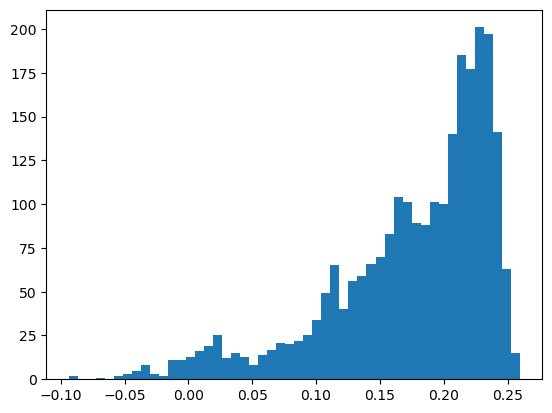

In [175]:
plt.hist(df['AnomalyScore'], bins=50)
plt.show()

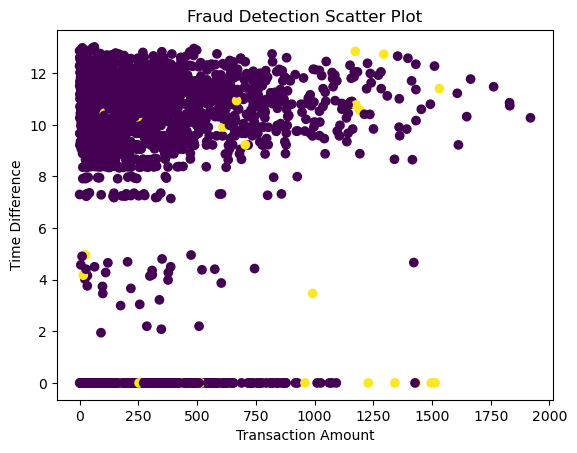

In [176]:
plt.scatter(df['TransactionAmount'], df['LogTimeDiff'], c=df['Fraud'])
plt.xlabel('Transaction Amount')
plt.ylabel('Time Difference')
plt.title('Fraud Detection Scatter Plot')
plt.show()

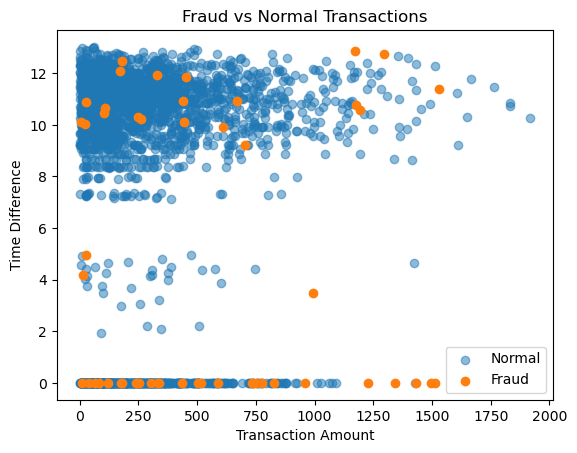

In [177]:
normal = df[df['Fraud'] == 0]
fraud = df[df['Fraud'] == 1]

plt.scatter(normal['TransactionAmount'], normal['LogTimeDiff'], label='Normal', alpha=0.5)
plt.scatter(fraud['TransactionAmount'], fraud['LogTimeDiff'], label='Fraud')

plt.xlabel('Transaction Amount')
plt.ylabel('Time Difference')
plt.title('Fraud vs Normal Transactions')
plt.legend()
plt.show()

C:\Users\nihar\AppData\Local\Temp\ipykernel_8668\1769784458.py:6: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



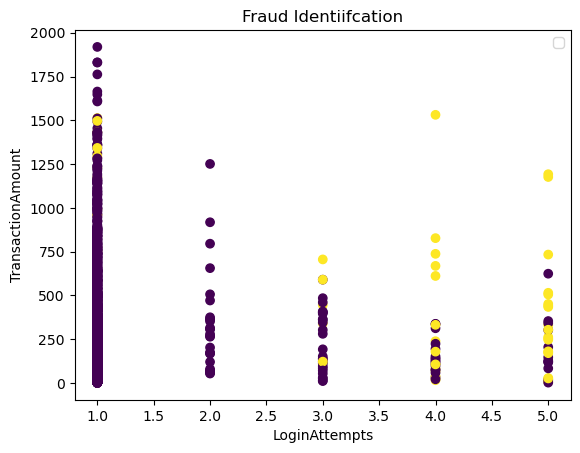

In [178]:
plt.scatter(df['LoginAttempts'], df['TransactionAmount'], c=df['Fraud'])

plt.xlabel('LoginAttempts')
plt.ylabel('TransactionAmount')
plt.title('Fraud Identiifcation')
plt.legend()
plt.show()

### Task 3: GenAI-Powered Contextual Dashboard

In [179]:
features_for_explain = [
    'TransactionAmount',
    'LogTimeDiff',
    'LoginAttempts',
    'TransactionDuration',
    'HighLoginAttempts',
    'FastTransaction',
    'RapidTransactions',
    'VeryRapid',
    'HighAmount',
    'Channel'
]

In [180]:
#Rule based explanation
def explain_transaction(row):
    reasons = []
    
    if row['HighLoginAttempts'] == 1:
        reasons.append("multiple login attempts")
        
    if row['VeryRapid'] == 1:
        reasons.append("very rapid transactions")
        
    if row['FastTransaction'] == 1:
        reasons.append("transaction executed very quickly")
        
    if row['HighAmount'] == 1:
        reasons.append("high transaction amount")

    if row['Channel']==1:
        reasons.append("Different channel")
        
    if len(reasons) == 0:
        return "Transaction flagged as anomalous due to unusual pattern"
    
    return "Transaction flagged due to: " + ", ".join(reasons)

In [181]:
fraud_df=df[df['Fraud']==1].copy()

fraud_df['Explanation']=fraud_df.apply(explain_transaction,axis=1)

fraud_df[['TransactionAmount','LoginAttempts','Channel','Explanation']].head(20)

,TransactionAmount,LoginAttempts,Channel,Explanation
54,733.29,5,0,"Transaction flagged due to: multiple login attempts, very rapid transactions, high transaction amount"
84,774.48,1,1,"Transaction flagged due to: very rapid transactions, high transaction amount, Different channel"
99,1228.81,1,0,"Transaction flagged due to: very rapid transactions, high transaction amount"
100,331.32,5,1,"Transaction flagged due to: multiple login attempts, Different channel"
203,737.46,4,1,"Transaction flagged due to: multiple login attempts, very rapid transactions, high transaction amount, Different channel"
325,445.41,3,0,Transaction flagged due to: multiple login attempts
371,451.31,5,0,Transaction flagged due to: multiple login attempts
429,1531.31,4,2,"Transaction flagged due to: multiple login attempts, high transaction amount"
440,340.13,3,1,"Transaction flagged due to: multiple login attempts, very rapid transactions, Different channel"
483,827.14,4,1,"Transaction flagged due to: multiple login attempts, very rapid transactions, high transaction amount, Different channel"


In [182]:
fraud_df.shape

(51, 16)

In [183]:
client = Groq(api_key="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")
def explain_with_llm(row):
    prompt = f"""
    You are a fraud detection expert.

    The currency is Indian Rupees (₹). Always use 'Rs.' instead of '$'.

    Explain why this transaction is suspicious:

    Amount: Rs. {row['TransactionAmount']}
    Login Attempts: {row['LoginAttempts']}
    LogTimeDiff: {row['LogTimeDiff']}

    Give a short explanation.
    """

    completion = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        max_completion_tokens=300
     )

    return completion.choices[0].message.content

In [184]:
fraud_df['LLM_Explanation'] = fraud_df.apply(explain_with_llm, axis=1)

In [185]:
def clean_text(text):
    text = text.replace('\\n', '\n')
    text = re.sub(r"\*\*", "", text)  # remove bold **
    return text

fraud_df['Clean_Explanation'] = fraud_df['LLM_Explanation'].apply(clean_text)

In [186]:
print(fraud_df['LLM_Explanation'].iloc[0])

The transaction is flagged because a relatively small purchase (Rs 733.29) was made after **five consecutive login attempts** with **no time gap (LogTimeDiff = 0.0)**. This pattern suggests a rapid‑fire login‑brute‑force or credential‑stuffing attack, where an attacker cycles through passwords until one works and immediately proceeds to a purchase. The lack of any time delay between attempts indicates automated behavior, making the transaction highly suspicious.


#### Building Dashboard

In [189]:
fraud_df['LoginAttempts'] = fraud_df['LoginAttempts'].astype(int)
fraud_df['TransactionAmount'] = fraud_df['TransactionAmount'].astype(float)
fraud_df['TimeDiff'] = fraud_df['TimeDiff'].fillna(0)

# Widgets
amount_slider = widgets.IntSlider(
    value=int(fraud_df['TransactionAmount'].min()),
    min=int(fraud_df['TransactionAmount'].min()),
    max=int(fraud_df['TransactionAmount'].max()),
    step=10,
    description='Min Amount'
)

login_dropdown = widgets.Dropdown(
    options=sorted(fraud_df['LoginAttempts'].unique()),
    value=int(fraud_df['LoginAttempts'].min()),
    description='LoginAttempts'
)

time_slider = widgets.FloatSlider(
    value=float(fraud_df['TimeDiff'].quantile(0.9)),
    min=float(fraud_df['TimeDiff'].min()),
    max=float(fraud_df['TimeDiff'].max()),
    step=(fraud_df['TimeDiff'].max() - fraud_df['TimeDiff'].min()) / 50,
    description='Max TimeDiff'
)

txn_dropdown = widgets.Dropdown(
    options=['None'],
    value='None',
    description='Transaction'
)

out = widgets.Output()

def update_dashboard(change=None):
    with out:
        out.clear_output(wait=True)

        temp_df = fraud_df.copy()

        # FILTERS
        temp_df = temp_df[
            (temp_df['TransactionAmount'] >= amount_slider.value) &
            (temp_df['LoginAttempts'] == login_dropdown.value) &
            (temp_df['TimeDiff'] <= time_slider.value)  
        ]

        if temp_df.empty:
            txn_dropdown.options = ['None']
            print("No data after filtering")
            return

        # SORT for visibility
        temp_df = temp_df.sort_values('TimeDiff')

        # UPDATE DROPDOWN
        options = ['None'] + temp_df.index.tolist()
        txn_dropdown.options = options

        if txn_dropdown.value not in options:
            txn_dropdown.value = 'None'

        print("Fraud Dashboard")
        print(f"Rows after filtering: {len(temp_df)}")
        print(f"LoginAttempts = {login_dropdown.value}")
        print(f"Max TimeDiff = {time_slider.value:.2f}")

        # TABLE
        if txn_dropdown.value == 'None':
            display(
                temp_df[['TransactionAmount','LoginAttempts','TimeDiff']]
            )

            print("\nLLM Explanations (Top 3)")
            if 'LLM_Explanation' in temp_df.columns:
                for i, (_, row) in enumerate(temp_df.head(3).iterrows(), 1):
                    print(f"\n🔹 Case {i}")
                    print(row['LLM_Explanation'])

        else:
            idx = txn_dropdown.value
            display(
                temp_df.loc[[idx]][
                    ['TransactionAmount','LoginAttempts','TimeDiff']
                ]
            )

            print("\nLLM Explanation")
            print(temp_df.loc[idx].get('LLM_Explanation', "No explanation"))

        # CHARTS
        fig1 = px.scatter(
            temp_df,
            x='TransactionAmount',
            y='TimeDiff',
            color='LoginAttempts',
            size='TransactionAmount',
            title='Fraud Pattern'
        )
        fig1.show()

        fig2 = px.histogram(temp_df, x='TransactionAmount')
        fig2.show()

        fig3 = px.histogram(temp_df, x='TimeDiff')
        fig3.show()

        top_df = temp_df.sort_values('TransactionAmount', ascending=False).head(10)
        fig4 = px.bar(top_df, x=top_df.index.astype(str), y='TransactionAmount')
        fig4.show()


# LINK WIDGETS
amount_slider.observe(update_dashboard, names='value')
login_dropdown.observe(update_dashboard, names='value')
time_slider.observe(update_dashboard, names='value')
txn_dropdown.observe(update_dashboard, names='value')

# DISPLAY
display(
    amount_slider,
    login_dropdown,
    time_slider,
    txn_dropdown,
    out
)

update_dashboard()

IntSlider(value=6, description='Min Amount', max=1531, min=6, step=10)

Dropdown(description='LoginAttempts', options=(np.int64(1), np.int64(3), np.int64(4), np.int64(5)), value=np.i…

FloatSlider(value=141169.0, description='Max TimeDiff', max=378762.0, step=7575.24)

Dropdown(description='Transaction', options=('None',), value='None')

Output()

### Task 4: Workflow Automation

In [70]:
def run_fraud_pipeline(file_path="transactions.csv"):
    
    print("Starting Daily Fraud Monitoring Pipeline...\n")
    
    df = pd.read_csv(file_path)
    
    df['TransactionDate']=pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y %H:%M')
    df = df.sort_values(['AccountID', 'TransactionDate'])

    df['PrevTxn'] = df.groupby('AccountID')['TransactionDate'].shift(1)
    df['TimeDiff'] = (df['TransactionDate'] - df['PrevTxn']).dt.total_seconds()
    df['TimeDiff'] = df['TimeDiff'].fillna(0)

    df['LogTimeDiff'] = np.log1p(df['TimeDiff'])
    df['HighLoginAttempts'] = (df['LoginAttempts'] >= 3).astype(int)
    df['FastTransaction'] = (df['TransactionDuration'] <= 2).astype(int)
    df['RapidTransactions'] = (df['TimeDiff'] < 60).astype(int)
    df['HighAmount'] = (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.9)).astype(int)

    features = [
        'TransactionAmount','LogTimeDiff','LoginAttempts',
        'TransactionDuration','AccountBalance',
        'HighLoginAttempts','FastTransaction','RapidTransactions','HighAmount'
    ]

    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])

    model = IsolationForest(contamination=0.02, random_state=42)
    df['Fraud'] = model.fit_predict(X)
    df['Fraud'] = df['Fraud'].apply(lambda x: 1 if x == -1 else 0)

    fraud_df = df[df['Fraud'] == 1].copy()

    def explain(row):
        reasons = []
        if row['HighLoginAttempts']: reasons.append("multiple login attempts")
        if row['RapidTransactions']: reasons.append("rapid transactions")
        if row['FastTransaction']: reasons.append("fast execution")
        if row['HighAmount']: reasons.append("high amount")
        return ", ".join(reasons) if reasons else "anomalous pattern"

    fraud_df['Explanation'] = fraud_df.apply(explain, axis=1)

    #Save Reports
    df.to_csv("full_data.csv", index=False)
    fraud_df.to_csv("fraud_data.csv", index=False)
    fraud_df.to_excel("fraud_report.xlsx", index=False)

    # Summary report
    summary = pd.DataFrame({
        "Total Transactions": [len(df)],
        "Fraud Transactions": [len(fraud_df)],
        "Fraud %": [(len(fraud_df)/len(df))*100]
    })

    summary.to_excel("summary_report.xlsx", index=False)

    
    # Alerts
    
    fraud_count = len(fraud_df)

    print("Summary")
    print(summary)

    if fraud_count > 0:
        print(f"\n ALERT: {fraud_count} suspicious transactions detected!")
    else:
        print("\n No suspicious transactions")

    print("\n Reports Generated:")
    print(" - fraud_report.xlsx")
    print(" - summary_report.xlsx")
    print(" - fraud_data.csv")

    print("\n Pipeline Completed Successfully")

    return df, fraud_df

In [71]:
df1, fraud_df1 = run_fraud_pipeline("Fraud Detection Data.csv")

Starting Daily Fraud Monitoring Pipeline...

Summary
   Total Transactions  Fraud Transactions   Fraud %
0                2512                  51  2.030255

 ALERT: 51 suspicious transactions detected!

 Reports Generated:
 - fraud_report.xlsx
 - summary_report.xlsx
 - fraud_data.csv

 Pipeline Completed Successfully


### Task 5: Final Integration & Testing

In [73]:
print(df.shape)
print(fraud_df.shape)

(2512, 14)
(51, 17)


In [74]:
#Fraud is actually detected
fraud_df['Fraud'].value_counts()

Fraud
1    51
Name: count, dtype: int64

In [75]:
#Validating Features
df[['TransactionAmount','LogTimeDiff','LoginAttempts']].describe()

,TransactionAmount,LogTimeDiff,LoginAttempts
count,2512.000000,2512.000000,2512.000000
mean,297.593778,8.567765,1.124602
std,291.946243,4.442397,0.602662
min,0.260000,0.000000,1.000000
25%,81.885000,8.663239,1.000000
50%,211.140000,10.568711,1.000000
75%,414.527500,11.446265,1.000000
max,1919.110000,13.018615,5.000000


In [76]:
#Validating Model Behavior
df['Fraud'].value_counts(normalize=True)

Fraud
0    0.979697
1    0.020303
Name: proportion, dtype: float64

In [77]:
#Comparing Fraud vs Normal
df.groupby('Fraud')[['TransactionAmount','LoginAttempts','LogTimeDiff']].mean()

,TransactionAmount,LoginAttempts,LogTimeDiff
Fraud,,,
0,292.171312,1.072735,8.66153
1,559.254314,3.627451,4.04316


In [93]:
#Testing with Sample Suspicious Data

test_data = pd.DataFrame({
    'TransactionAmount': [1000],
    'LoginAttempts': [5],
    'TransactionDuration': [1],
    'AccountBalance': [5000],
    'TimeDiff': [10]
})

test_data['LogTimeDiff'] = np.log1p(test_data['TimeDiff'])
test_data['HighLoginAttempts'] = 1
test_data['FastTransaction'] = 1
test_data['RapidTransactions'] = 1
test_data['HighAmount'] = 1
test_data['Channel']=1
test_data['VeryRapid']=0.5

X_test = scaler.transform(test_data[features])
model.predict(X_test)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Channel
- VeryRapid


In [81]:
#LLM Explanation Validation
fraud_df[['LLM_Explanation']].head()

,LLM_Explanation
54,"**Why this transaction looks suspicious**\n\n- **Multiple login attempts (5) in a single session** – a legitimate user rarely needs to re‑authenticate several times for a modest purchase.\n- **Zero time gap between the attempts (`LogTimeDiff: 0.0`)** – the logins occurred almost simultaneously, which is typical of automated scripts or bots trying different credentials.\n- **Small, non‑rounded amount (Rs. 733.29)** – fraudsters often use odd‑cent values to test stolen card numbers without triggering simple threshold alerts.\n\nTogether, the rapid, repeated logins and the atypical amount suggest a scripted, possibly credential‑stuffing attack rather than a normal customer purchase."
84,"The transaction is suspicious because the purchase was made **immediately after login** – the log‑time difference is 0.0 seconds. This suggests the user didn’t have any normal browsing or verification period, which is a common pattern for automated or scripted fraud attempts. Even though the amount (Rs. 774.48) is modest, the instantaneous nature of the activity raises a red flag."
99,"**Why this transaction looks suspicious**\n\n- **Amount (Rs. 1228.81)** – The value is just under a typical “round‑off” threshold (e.g., Rs. 1,250 or Rs. 1,000). Fraudsters often choose amounts that are close to, but not exactly, common limits to avoid triggering automatic alerts while still moving a sizable sum.\n\n- **Login attempts (1)** – Only a single login was recorded before the purchase. Legitimate shoppers usually have a few page views or cart actions before buying; a one‑step flow can indicate a scripted or automated checkout.\n\n- **LogTimeDiff (0.0 seconds)** – The time between the login event and the transaction is essentially zero, meaning the purchase was made instantly after authentication. This rapid succession is atypical for genuine users, who normally spend some time browsing or confirming details, and is a hallmark of bots or credential‑stuffing attacks.\n\nTogether, the near‑round amount, lack of any prior activity, and an instantaneous purchase raise red flags that the transaction may be fraudulent."
100,"The transaction raises a red flag because a relatively small amount (Rs. 331.32) was attempted after **five consecutive login attempts** within a very short window—only **≈ 12 seconds** between the first and last attempt. Such rapid, repeated logins suggest a possible brute‑force or credential‑stuffing attack, and the fact that a purchase was made immediately afterward indicates the attacker may have succeeded in gaining access and trying to move funds before the account holder can react. This pattern of high‑frequency logins followed by an immediate transaction is typical of fraudulent behavior."
133,"**Why this transaction looks suspicious**\n\n- **Zero time gap (LogTimeDiff = 0.0):** The transaction was recorded at exactly the same moment the user logged in. Legitimate purchases usually have a few seconds‑to‑minutes of browsing or checkout time. A zero‑second interval often signals an automated or scripted action that tries to complete a payment immediately after a credential check. \n\n- **Single login attempt:** Only one login attempt was needed, which can happen with stolen credentials that are already valid. Coupled with the instant transaction, it suggests the attacker didn’t need to “test” the account—they could use it straight away. \n\n- **Unusual amount (Rs. 820.46):** While not huge, the amount is specific enough to be a test transaction (e.g., checking whether the card works) rather than a typical round‑off purchase. Fraudsters often use modest, non‑round amounts for validation before scaling up.\n\n**Bottom line:**"


In [82]:
#Alert System Test
if len(fraud_df) > 0:
    print("ALERT WORKING")

ALERT WORKING


In [83]:
#Validated Pipeline Output Files 
#- fraud_report.xlsx
#fraud_data.csv
#summary_report.xlsx

In [84]:
#Done Dashboard Testing
#Moved slider - Data changes    
#Select txn - Details change  
#Graph updates - Yes             
#Explanation  - Shows correctly 
